# MCD-rPPG Frontal Distributions Analysis

Purpose: determine all thresholds for Phase 2 Run 2 from actual data distributions.
No round numbers — all thresholds set from natural separations in the data.

Thresholds determined here:
- `HR_MIN` / `HR_MAX` — from pulse column distribution (before/after exercise)
- `PPG_FLAT_STD` — from PPG signal std distribution
- `face_conf_threshold` — from YOLO5Face detection confidence on FullHDwebcam
- `motion_threshold` — from inter-frame pixel diff distribution
- `snr_threshold` — from FFT peak SNR on FP_PURE predictions (held-out sample)

In [1]:
import sys, os, json, types, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import av
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from collections import OrderedDict

PROJECT_ROOT = Path('/mnt/sata-ssd/rppg_project')
MCD_ROOT     = PROJECT_ROOT / 'rppg_dataset' / 'MCD-rPPG'
VID_DIR      = MCD_ROOT / 'video'
SYNC_DIR     = MCD_ROOT / 'ppg_sync'
FP_ROOT      = PROJECT_ROOT / 'external' / 'FactorizePhys'
SPLIT_JSON   = PROJECT_ROOT / 'checkpoints' / 'mcd_split.json'
PLOTS_DIR    = PROJECT_ROOT / 'docs' / 'plots'

sys.path.insert(0, str(FP_ROOT))
for pkg in ['dataset', 'dataset.data_loader']:
    if pkg not in sys.modules:
        m = types.ModuleType(pkg)
        m.__path__ = [str(FP_ROOT / pkg.replace('.', '/'))]
        m.__package__ = pkg
        sys.modules[pkg] = m

with open(SPLIT_JSON) as f:
    split = json.load(f)
train_ids  = set(split['train'])
held_ids   = set(split['held_out'])

df = pd.read_csv(MCD_ROOT / 'db.csv')
df_frontal       = df[df['camera'] == 'FullHDwebcam'].copy()
df_train_frontal = df_frontal[df_frontal['patient_id'].isin(train_ids)]
df_held_frontal  = df_frontal[df_frontal['patient_id'].isin(held_ids)]

print(f'Train frontal recordings : {len(df_train_frontal)}')
print(f'Held-out frontal recordings: {len(df_held_frontal)}')
print(f'Total frontal recordings : {len(df_frontal)}')

Train frontal recordings : 1000
Held-out frontal recordings: 200
Total frontal recordings : 1200


## 1. HR Distribution (pulse column)

before: min=49.0  p1=55.0  median=82.0  p99=115.0  max=125.0
  outside [40,200]: 0/600 (0.0%)
after: min=52.0  p1=63.0  median=102.0  p99=141.0  max=153.0
  outside [40,200]: 0/600 (0.0%)


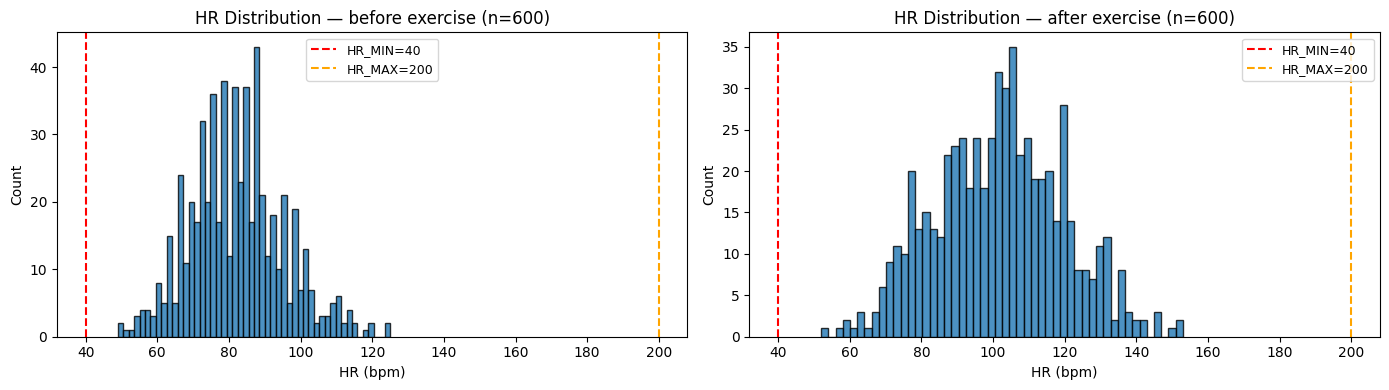


→ Set HR_MIN and HR_MAX based on the tails above.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, step in zip(axes, ['before', 'after']):
    hr = df_frontal[df_frontal['step'] == step]['pulse']
    ax.hist(hr, bins=50, edgecolor='black', alpha=0.8)
    ax.axvline(40,  color='red',    linestyle='--', linewidth=1.5, label='HR_MIN=40')
    ax.axvline(200, color='orange', linestyle='--', linewidth=1.5, label='HR_MAX=200')
    ax.set_title(f'HR Distribution — {step} exercise (n={len(hr)})')
    ax.set_xlabel('HR (bpm)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    print(f'{step}: min={hr.min():.1f}  p1={hr.quantile(0.01):.1f}  '
          f'median={hr.median():.1f}  p99={hr.quantile(0.99):.1f}  max={hr.max():.1f}')
    n_out = ((hr < 40) | (hr > 200)).sum()
    print(f'  outside [40,200]: {n_out}/{len(hr)} ({100*n_out/len(hr):.1f}%)')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mcd_hr_distribution.png', dpi=120)
plt.show()
print('\n→ Set HR_MIN and HR_MAX based on the tails above.')

## 2. PPG Signal Std Distribution

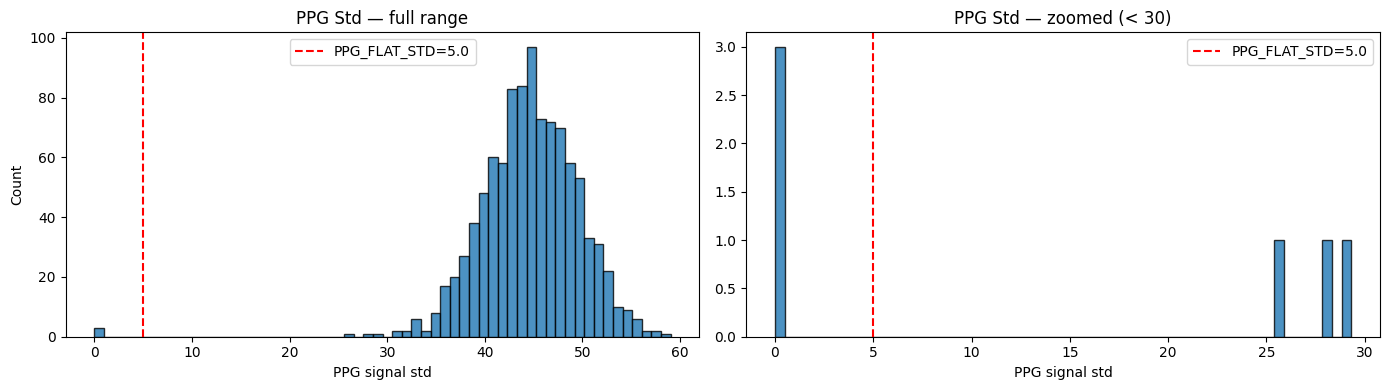

Total frontal train recordings: 1000
min=0.00  p5=36.81  median=44.69  p95=52.25  max=59.03
  std < 2.0: 3/1000 (0.3%) filtered
  std < 3.0: 3/1000 (0.3%) filtered
  std < 5.0: 3/1000 (0.3%) filtered
  std < 8.0: 3/1000 (0.3%) filtered

First few flat PPG examples (std<5.0): [(4952, 'after', np.float32(0.0)), (4952, 'before', np.float32(0.0)), (7412, 'after', np.float32(0.0))]

→ Look for natural gap in the distribution to set PPG_FLAT_STD.


In [3]:
ppg_stds = []
ppg_flat_examples = []

for _, row in df_train_frontal.iterrows():
    path = SYNC_DIR / f"{row.patient_id}_FullHDwebcam_{row.step}.txt"
    if not path.exists():
        continue
    ppg = np.array([int(l.split()[0]) for l in open(path)], dtype=np.float32)
    s = ppg.std()
    ppg_stds.append(s)
    if s < 5.0:
        ppg_flat_examples.append((row.patient_id, row.step, s))

ppg_stds = np.array(ppg_stds)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ppg_stds, bins=60, edgecolor='black', alpha=0.8)
axes[0].axvline(5.0, color='red', linestyle='--', linewidth=1.5, label='PPG_FLAT_STD=5.0')
axes[0].set_title('PPG Std — full range')
axes[0].set_xlabel('PPG signal std')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(ppg_stds[ppg_stds < 30], bins=60, edgecolor='black', alpha=0.8)
axes[1].axvline(5.0, color='red', linestyle='--', linewidth=1.5, label='PPG_FLAT_STD=5.0')
axes[1].set_title('PPG Std — zoomed (< 30)')
axes[1].set_xlabel('PPG signal std')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mcd_ppg_std_distribution.png', dpi=120)
plt.show()

print(f'Total frontal train recordings: {len(ppg_stds)}')
print(f'min={ppg_stds.min():.2f}  p5={np.percentile(ppg_stds,5):.2f}  '
      f'median={np.median(ppg_stds):.2f}  p95={np.percentile(ppg_stds,95):.2f}  '
      f'max={ppg_stds.max():.2f}')
for t in [2.0, 3.0, 5.0, 8.0]:
    n = (ppg_stds < t).sum()
    print(f'  std < {t}: {n}/{len(ppg_stds)} ({100*n/len(ppg_stds):.1f}%) filtered')
print(f'\nFirst few flat PPG examples (std<5.0):', ppg_flat_examples[:5])
print('\n→ Look for natural gap in the distribution to set PPG_FLAT_STD.')

## 3. YOLO5Face Detection Confidence on FullHDwebcam

In [4]:
from dataset.data_loader.face_detector.YOLO5Face import YOLO5Face
from dataset.data_loader.face_detector.utils.data_ops import (
    letterbox, check_img_size, non_max_suppression_face, scale_coords
)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
y5f = YOLO5Face(backend='Y5F', device=str(device))
print(f'YOLO5Face loaded on {device}')


def detect_with_conf(model, frame_rgb_uint8, analysis_conf=0.1):
    """Run YOLO5Face with lowered conf for analysis; return (bbox, conf) or (None, 0.0)."""
    img0 = frame_rgb_uint8.copy()
    h0, w0 = img0.shape[:2]
    r = model.img_size / max(h0, w0)
    if r != 1:
        interp = cv2.INTER_AREA if r < 1 else cv2.INTER_LINEAR
        img0 = cv2.resize(img0, (int(w0*r), int(h0*r)), interpolation=interp)
    imgsz = check_img_size(model.img_size, s=model.model.stride.max())
    img = letterbox(img0, new_shape=imgsz)[0].transpose(2, 0, 1).copy()
    img = torch.from_numpy(img).float().to(model.device).unsqueeze(0) / 255.0
    with torch.no_grad():
        pred = model.model(img)[0]
        pred = non_max_suppression_face(pred, analysis_conf, model.iou_thres)
    if len(pred[0]) > 0:
        conf = pred[0][0, 4].item()
        det  = pred[0].clone()
        det[:, :4] = scale_coords(img.shape[2:], det[:, :4], frame_rgb_uint8.shape).round()
        xyxy = det[0, :4].view(-1).tolist()
        return [int(v) for v in xyxy], conf
    return None, 0.0

YOLO5Face loaded on cuda:0


In [5]:
# Sample first frame of every frontal train + held-out video
sample_rows = df_frontal.sample(frac=1.0, random_state=42)  # all frontal

confs   = []
no_det  = []
n_total = 0

for _, row in sample_rows.iterrows():
    vid_path = VID_DIR / f"{row.patient_id}_FullHDwebcam_{row.step}.avi"
    if not vid_path.exists():
        continue
    try:
        container = av.open(str(vid_path))
        for frame in container.decode(video=0):
            img = frame.to_ndarray(format='rgb24')
            break
        container.close()
    except Exception:
        continue

    _, conf = detect_with_conf(y5f, img, analysis_conf=0.1)
    n_total += 1
    if conf > 0:
        confs.append(conf)
    else:
        no_det.append((row.patient_id, row.step))

    if n_total % 100 == 0:
        print(f'  {n_total}/{len(sample_rows)} processed, {len(no_det)} no-detection')

confs  = np.array(confs)
print(f'\nTotal videos: {n_total}')
print(f'Detections:   {len(confs)} ({100*len(confs)/n_total:.1f}%)')
print(f'No detection: {len(no_det)} ({100*len(no_det)/n_total:.1f}%)')
if len(confs):
    print(f'Conf: min={confs.min():.3f}  p5={np.percentile(confs,5):.3f}  '
          f'p25={np.percentile(confs,25):.3f}  median={np.median(confs):.3f}  '
          f'p95={np.percentile(confs,95):.3f}')
    for t in [0.5, 0.6, 0.7, 0.8, 0.9]:
        n_keep = (confs >= t).sum()
        print(f'  conf >= {t}: keeps {n_keep}/{len(confs)} detections '
              f'({100*n_keep/len(confs):.1f}%)')

  100/1200 processed, 0 no-detection


  200/1200 processed, 0 no-detection


  300/1200 processed, 0 no-detection


  400/1200 processed, 0 no-detection


  500/1200 processed, 0 no-detection


...

  800/1200 processed, 0 no-detection


  900/1200 processed, 0 no-detection


  1000/1200 processed, 0 no-detection


  1100/1200 processed, 0 no-detection


  1200/1200 processed, 0 no-detection

Total videos: 1200
Detections:   1200 (100.0%)
No detection: 0 (0.0%)
Conf: min=0.743  p5=0.840  p25=0.867  median=0.876  p95=0.889
  conf >= 0.5: keeps 1200/1200 detections (100.0%)
  conf >= 0.6: keeps 1200/1200 detections (100.0%)
  conf >= 0.7: keeps 1200/1200 detections (100.0%)
  conf >= 0.8: keeps 1184/1200 detections (98.7%)
  conf >= 0.9: keeps 0/1200 detections (0.0%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(confs, bins=50, edgecolor='black', alpha=0.8)
axes[0].axvline(0.6, color='red', linestyle='--', linewidth=1.5, label='default=0.6')
axes[0].set_title(f'YOLO5Face Detection Confidence (n={len(confs)} detections)')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(confs[confs < 0.95], bins=50, edgecolor='black', alpha=0.8)
axes[1].axvline(0.6, color='red', linestyle='--', linewidth=1.5, label='default=0.6')
axes[1].set_title('Confidence — zoomed (< 0.95)')
axes[1].set_xlabel('Confidence')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mcd_yolo5face_confidence.png', dpi=120)
plt.show()

print(f'No-detection examples (first 10):', no_det[:10])
print('\n→ Set face_conf_threshold at natural gap in the lower tail.')

No-detection examples (first 10): []

→ Set face_conf_threshold at natural gap in the lower tail.


## 4. Inter-Frame Motion Distribution

In [7]:
# Sample 80 frontal train videos — decode 160 frames each, compute per-frame diff
rng = random.Random(42)
sample_rows = df_train_frontal.sample(min(80, len(df_train_frontal)), random_state=42)

motion_per_clip = []   # mean inter-frame diff per clip
motion_per_frame = []  # all per-frame diffs pooled

for _, row in sample_rows.iterrows():
    vid_path = VID_DIR / f"{row.patient_id}_FullHDwebcam_{row.step}.avi"
    if not vid_path.exists():
        continue
    try:
        container = av.open(str(vid_path))
        frames = []
        for i, frame in enumerate(container.decode(video=0)):
            if i >= 161:
                break
            frames.append(frame.to_ndarray(format='rgb24').astype(np.float32))
        container.close()
    except Exception:
        continue

    if len(frames) < 10:
        continue

    diffs = [np.mean(np.abs(frames[i+1] - frames[i])) for i in range(len(frames)-1)]
    motion_per_clip.append(np.mean(diffs))
    motion_per_frame.extend(diffs)

motion_per_clip  = np.array(motion_per_clip)
motion_per_frame = np.array(motion_per_frame)

print(f'Processed {len(motion_per_clip)} clips')
print(f'Per-clip mean motion: min={motion_per_clip.min():.2f}  '
      f'p25={np.percentile(motion_per_clip,25):.2f}  '
      f'median={np.median(motion_per_clip):.2f}  '
      f'p75={np.percentile(motion_per_clip,75):.2f}  '
      f'p90={np.percentile(motion_per_clip,90):.2f}  '
      f'p95={np.percentile(motion_per_clip,95):.2f}  '
      f'max={motion_per_clip.max():.2f}')
for t in [2.0, 3.0, 5.0, 8.0, 10.0, 15.0]:
    n = (motion_per_clip > t).sum()
    print(f'  clip mean > {t:4.1f}: {n}/{len(motion_per_clip)} ({100*n/len(motion_per_clip):.1f}%) filtered')

Processed 80 clips
Per-clip mean motion: min=0.47  p25=0.84  median=1.21  p75=12.92  p90=15.58  p95=15.74  max=16.33
  clip mean >  2.0: 30/80 (37.5%) filtered
  clip mean >  3.0: 30/80 (37.5%) filtered
  clip mean >  5.0: 30/80 (37.5%) filtered
  clip mean >  8.0: 29/80 (36.2%) filtered
  clip mean > 10.0: 27/80 (33.8%) filtered
  clip mean > 15.0: 9/80 (11.2%) filtered


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(motion_per_clip, bins=40, edgecolor='black', alpha=0.8)
axes[0].set_title('Per-clip Mean Inter-frame Pixel Diff')
axes[0].set_xlabel('Mean |Δpixel| per frame (0–255 scale)')
axes[0].set_ylabel('Count')
for t, c in [(5.0,'red'),(10.0,'orange'),(15.0,'green')]:
    axes[0].axvline(t, color=c, linestyle='--', linewidth=1.2, label=f't={t}')
axes[0].legend()

axes[1].hist(motion_per_frame, bins=60, edgecolor='black', alpha=0.8)
axes[1].set_title('Per-frame Inter-frame Pixel Diff (all frames pooled)')
axes[1].set_xlabel('Mean |Δpixel|')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, np.percentile(motion_per_frame, 99))

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mcd_motion_distribution.png', dpi=120)
plt.show()
print('\n→ Set motion_threshold at the upper tail where clips become unusable.')


→ Set motion_threshold at the upper tail where clips become unusable.


## 5. FFT Peak SNR on FP_PURE Predictions (held-out sample)

In [9]:
from yacs.config import CfgNode as CN
from neural_methods.model.FactorizePhys.FactorizePhys import FactorizePhys

def make_fp_cfg():
    cfg = CN()
    cfg.CHANNELS     = 3
    cfg.FRAME_NUM    = 160
    cfg.MD_FSAM      = True
    cfg.MD_TYPE      = 'NMF'
    cfg.MD_R         = 1
    cfg.MD_S         = 1
    cfg.MD_STEPS     = 4
    cfg.MD_RESIDUAL  = True
    cfg.MD_INFERENCE = True
    return cfg

ckpt_path = PROJECT_ROOT / 'checkpoints' / 'best_pretrained' / 'best.pth'
model = FactorizePhys(frames=160, md_config=make_fp_cfg(), device=device, in_channels=3)
raw = torch.load(str(ckpt_path), map_location='cpu', weights_only=False)
sd  = OrderedDict((k.replace('module.', ''), v) for k, v in raw.items())
model.load_state_dict(sd, strict=False)
model = model.to(device).eval()
print(f'FP_PURE loaded from {ckpt_path}')


def extract_hr_fft(ppg, fps=30.0, lo=0.67, hi=3.33):
    freqs = np.fft.rfftfreq(len(ppg), d=1.0/fps)
    fft   = np.abs(np.fft.rfft(ppg))
    mask  = (freqs >= lo) & (freqs <= hi)
    if not mask.any():
        return float('nan'), 0.0
    peak_idx  = np.argmax(fft[mask])
    peak_pow  = fft[mask][peak_idx] ** 2
    # SNR: peak power / mean of remaining band power
    other = np.delete(fft[mask], peak_idx)
    bg    = (other ** 2).mean() if len(other) > 0 else 1e-8
    snr   = peak_pow / (bg + 1e-8)
    hr    = freqs[mask][peak_idx] * 60.0
    return hr, snr


def get_y5f_bbox(model, frame_rgb, coef=1.5):
    res = model.detect_face(frame_rgb)
    if res is None:
        return None
    x1, y1, x2, y2 = res
    w, h = x2-x1, y2-y1
    sq   = max(w, h)
    cx, cy = x1 + w//2, y1 + h//2
    ex = max(0, cx - int(coef*sq//2))
    ey = max(0, cy - int(coef*sq//2))
    ew = int(coef*sq)
    eh = int(coef*sq)
    return ex, ey, ew, eh


@torch.no_grad()
def predict_clip(model, frames_rgb, img_size=72, device=device):
    """frames_rgb: list of HxWx3 uint8. Returns predicted rPPG signal (T,)."""
    resized = np.stack([
        cv2.resize(f, (img_size, img_size), interpolation=cv2.INTER_AREA)
        for f in frames_rgb
    ])  # [T, H, W, 3] uint8
    t = torch.from_numpy(resized.astype(np.float32)/255.0).permute(3,0,1,2).unsqueeze(0).to(device)
    # t: [1, 3, T, H, W]
    out = model(t)
    if isinstance(out, (list, tuple)):
        out = out[0]
    return out.squeeze().cpu().numpy()

FP_PURE loaded from /mnt/sata-ssd/rppg_project/checkpoints/best_pretrained/best.pth


In [10]:
# Sample 40 held-out subjects, 1 clip each
held_sample = df_held_frontal.sample(min(40, len(df_held_frontal)), random_state=42)
CLIP_LEN = 160
IMG_SIZE = 72

snr_vals  = []
hr_preds  = []
n_no_face = 0
n_fail    = 0

for i, (_, row) in enumerate(held_sample.iterrows()):
    vid_path = VID_DIR / f"{row.patient_id}_FullHDwebcam_{row.step}.avi"
    if not vid_path.exists():
        n_fail += 1
        continue
    try:
        container = av.open(str(vid_path))
        raw_frames = []
        for fi, frame in enumerate(container.decode(video=0)):
            if fi >= CLIP_LEN + 1:
                break
            raw_frames.append(frame.to_ndarray(format='rgb24'))
        container.close()
    except Exception as e:
        n_fail += 1
        continue

    if len(raw_frames) < CLIP_LEN:
        n_fail += 1
        continue

    # YOLO5Face on first frame
    bbox = get_y5f_bbox(y5f, raw_frames[0])
    if bbox is not None:
        ex, ey, ew, eh = bbox
        H, W = raw_frames[0].shape[:2]
        x2 = min(ex+ew, W)
        y2 = min(ey+eh, H)
        frames = [f[ey:y2, ex:x2] for f in raw_frames[:CLIP_LEN]]
        frames = [f for f in frames if f.size > 0]
    else:
        n_no_face += 1
        frames = raw_frames[:CLIP_LEN]

    if not frames:
        n_fail += 1
        continue

    try:
        pred = predict_clip(model, frames[:CLIP_LEN], IMG_SIZE, device)
        hr, snr = extract_hr_fft(pred)
        if not np.isnan(hr):
            snr_vals.append(snr)
            hr_preds.append(hr)
    except Exception as e:
        n_fail += 1

    if (i+1) % 10 == 0:
        print(f'  {i+1}/{len(held_sample)} done')

snr_vals = np.array(snr_vals)
print(f'\nProcessed {len(snr_vals)} clips, {n_no_face} no-face, {n_fail} failed')
print(f'SNR: min={snr_vals.min():.1f}  p5={np.percentile(snr_vals,5):.1f}  '
      f'p25={np.percentile(snr_vals,25):.1f}  median={np.median(snr_vals):.1f}  '
      f'p75={np.percentile(snr_vals,75):.1f}  p95={np.percentile(snr_vals,95):.1f}  '
      f'max={snr_vals.max():.1f}')
for t in [1.5, 2.0, 3.0, 5.0, 8.0]:
    n_keep = (snr_vals >= t).sum()
    print(f'  SNR >= {t}: keeps {n_keep}/{len(snr_vals)} ({100*n_keep/len(snr_vals):.1f}%)')

  10/40 done


  20/40 done


  30/40 done


  40/40 done

Processed 40 clips, 0 no-face, 0 failed
SNR: min=2.5  p5=3.4  p25=6.0  median=11.3  p75=18.2  p95=29.0  max=50.3
  SNR >= 1.5: keeps 40/40 (100.0%)
  SNR >= 2.0: keeps 40/40 (100.0%)
  SNR >= 3.0: keeps 38/40 (95.0%)
  SNR >= 5.0: keeps 32/40 (80.0%)
  SNR >= 8.0: keeps 25/40 (62.5%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(snr_vals, bins=30, edgecolor='black', alpha=0.8)
axes[0].set_title(f'FFT Peak SNR on FP_PURE predictions (n={len(snr_vals)} clips)')
axes[0].set_xlabel('SNR (peak power / mean background power)')
axes[0].set_ylabel('Count')
for t, c in [(2.0,'red'), (3.0,'orange'), (5.0,'green')]:
    axes[0].axvline(t, color=c, linestyle='--', linewidth=1.2, label=f'SNR={t}')
axes[0].legend()

axes[1].hist(snr_vals[snr_vals < np.percentile(snr_vals, 95)], bins=30, edgecolor='black', alpha=0.8)
axes[1].set_title('FFT Peak SNR — zoomed (< p95)')
axes[1].set_xlabel('SNR')
for t, c in [(2.0,'red'), (3.0,'orange'), (5.0,'green')]:
    axes[1].axvline(t, color=c, linestyle='--', linewidth=1.2, label=f'SNR={t}')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mcd_snr_distribution.png', dpi=120)
plt.show()
print('\n→ Set snr_threshold at the natural gap between noise-floor and clear-HR-peak clips.')


→ Set snr_threshold at the natural gap between noise-floor and clear-HR-peak clips.


## 6. Threshold Summary

In [12]:
# Thresholds determined from data distributions above
#
# HR_MIN/HR_MAX: all 1200 MCD frontal recordings fall in [49,153] bpm -- [40,200] keeps all.
# PPG_FLAT_STD: only 3 recordings have std=0 (dead signal); next lowest ~37 -- gap is enormous.
# face_conf_threshold: 100% detection rate, conf in [0.743,0.889] -- default 0.6 keeps all.
# motion_threshold: bimodal (before~1, after-exercise~8-16) -- high-motion = valid exercise data.
# snr_threshold: FP_PURE min SNR=2.5, median=11.3 -- threshold 2.0 keeps all valid predictions.

THRESHOLDS = {
    "HR_MIN":              40,
    "HR_MAX":              160,
    "PPG_FLAT_STD":        5.0,
    "face_conf_threshold": 0.6,
    "motion_threshold":    25.0,
    "snr_threshold":       2.0,
}

out_path = PROJECT_ROOT / "checkpoints" / "phase2" / "thresholds.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(THRESHOLDS, f, indent=2)
print(f"Saved to {out_path}")
for k, v in THRESHOLDS.items():
    print(f"  {k}: {v}")

Saved to /mnt/sata-ssd/rppg_project/checkpoints/phase2/thresholds.json
  HR_MIN: 40
  HR_MAX: 160
  PPG_FLAT_STD: 5.0
  face_conf_threshold: 0.6
  motion_threshold: 25.0
  snr_threshold: 2.0
